# Track 1: Assignment 2
## Module A: Lightweight DBMS with B+ Tree Index.



---

## 1. Introduction

### Problem Statement

In rapidly scaling applications like the CallHub Phone Directory, efficient data storage and retrieval become critical challenges. As the directory grows from a few local contacts to a massive centralized database, traditional linear data structures fail to keep up:
- **Linear Search (O(n))**: Brute-force systems must scan records sequentially until a match is found. In the CallHub directory, locating a single emergency contact among 100,000 records could require up to 100,000 separate comparisons, causing severe system latency.
- **Poor Scalability**: Lookup time grows proportionally with database size
- **Real-time Demands**: Critical applications require guaranteed, ultra-low latency. A good Emergency call systems need sub-100ms contact lookups
- **Inefficient Range Queries**: Getting all contacts in a department requires scanning entire database

**Real-world Impact:**
- Call center lookup delays frustrate users
- System becomes unusable beyond 10,000 records
- Scaling to 1M+ contacts impossible with brute force

## Proposed Solution: B+ Tree DBMS

To address these bottlenecks in the CallHub Directory, this project implements a custom Database Management System powered by a B+ Tree indexing engine. A B+ Tree is a self-balancing tree data structure specifically optimized for disk- and memory-based database indexing.

### Key Advantages:
- **Search Performance**: O(log n) instead of O(n) → 10-100x faster lookups
- **Range Queries**: Linked leaf nodes enable efficient sequential access i.e. once the start of a department's ID range is found, the system can instantly grab all consecutive contacts without traversing the tree again.
- **Automatic Balancing**: Maintains its optimal, flat structure automatically, during insertions/deletions
- **Disk I/O Optimization**: Balanced structure minimizes disk access patterns
- **Scalability**: Handles millions of records while maintaining performance

### Real-world Application: CallHub Directory
This project implements B+ Tree DBMS for emergency contact management:
This module will build the B+ Tree from scratch to manage CallHub's records. It will scale from 100 initial test records to 50,100 records during automated benchmarking. We will rigorously compare the execution times of Insertion, Exact Search, Deletion, and Range Queries between our B+ Tree engine and a Brute Force approach, accompanied by Graphviz visualizations of the tree's internal node splitting and merging.

---

### Video Demonstration Link: https://drive.google.com/file/d/1xN_Y37VrH06vA1ZLJ_T7psXyXBtxz-l5/view?usp=sharing

In [1]:
import pandas as pd
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB
from database.db_manager import DatabaseManager
from database.performance_analyzer import PerformanceAnalyzer
from database.table import Table

---

# 2. Implementation

## System Architecture

The B+ Tree DBMS consists of the following layered components:

```
┌─────────────────────────────────┐
│   Main.ipynb (Demonstration)    │
└──────────────┬──────────────────┘
               │
┌──────────────▼──────────────────┐
│   DatabaseManager               │  • Multi-database management
│   • Database creation/deletion  │  • Table schema management
└──────────────┬──────────────────┘
               │
┌──────────────▼──────────────────┐
│   Table (Wrapper)               │  • Schema validation
│   • Type checking               │  • B+ Tree operations wrapper
└──────────────┬──────────────────┘
               │
┌──────────────▼──────────────────┐
│   BPlusTree (Core)              │  • Node management
│   • Insert/Delete/Search        │  • Automatic splitting/merging
│   • Range queries               │  • Tree rebalancing
│   • Visualization (Graphviz)    │  • Linked leaf nodes
└─────────────────────────────────┘
```

## B+ Tree Operations & Time Complexity

### Insert Operation - O(log n)

Process:
1. Find leaf node for key (O(log n))
2. Insert key-value pair
3. If node overflow: split into two nodes
4. Propagate separator key to parent (O(log n))
5. Cascade splits up tree if needed  
Result: Balanced tree maintained automatically


### Search Operation - O(log n)

Process:
1. Start at root, compare key with node keys
2. Follow pointer to appropriate child
3. Repeat until leaf node reached
4. Return value if key found  
Time: Tree depth = log_order(n), each level = O(1)


### Range Query Operation - O(log n + m) where m = results

Process:
1. Search for lower bound (O(log n))
2. Traverse linked leaf nodes sequentially
3. Collect all values in range
4. Stop when upper bound exceeded  
Advantage: Linked leaves avoid tree traversal


### Delete Operation - O(log n)

Process:
1. Find key in leaf node (O(log n))
2. Remove key-value pair
3. If underflow: borrow from sibling or merge
4. Update parent nodes (O(log n))
5. Cascade merges/borrows up tree  
Result: Minimum degree property maintained


## Key Implementation Features

| Feature | Implementation |
|---------|-----------------|
| **Node Capacity** | Order = 6: max 5 keys per node |
| **Leaf Structure** | Singly-linked for sequential range queries |
| **Splitting** | Automatic when node reaches capacity |
| **Merging** | Automatic when node underflows |
| **Key Type** | Unique integers (CallHub contact IDs) |
| **Value Type** | Contact dictionaries with name/phone/relationship |
| **Balance Guarantee** | All leaves at same depth |

---

## 2.1 Database Setup 

In [38]:
db_manager = DatabaseManager()

In [39]:
# db_manager.create_database('university')
db_manager.create_database('callhub_directory')

Database 'callhub_directory' created successfully.


True

In [40]:
db_manager.list_databases()

['callhub_directory']

In [41]:

contacts_schema = {
    "id": int,  # Unique identifier (primary key)
    "name": str,
    "phone": str,
    "email": str,
    "address": str
}

In [42]:
emergency_schema = {
    "id": int,  # Unique identifier (primary key)
    "contact_name": str,
    "phone": str,
    "relationship": str
}


In [43]:
# db_manager.create_table('university', 'professor', prof, order=6, search_key= "prof_id")
db_manager.create_table('callhub_directory', 'contacts', contacts_schema, order=6, search_key="id")

Table 'contacts' created successfully in 'callhub_directory'.


True

In [44]:
db_manager.create_table('callhub_directory', 'emergency_contacts', emergency_schema, order=6, search_key="id")

Table 'emergency_contacts' created successfully in 'callhub_directory'.


True

In [45]:
tables_name = db_manager.list_tables('callhub_directory')
tables_name

['contacts', 'emergency_contacts']

## B+ Tree Implementation 

### Creating a Dedicated Database for CallHub Directory

In this section, we demonstrate the B+ Tree implementation by creating a CallHub Directory database with real contact records. We will show insertion, search, deletion, range queries, and visualization before conducting performance analysis.

In [46]:


# Get the fresh emergency_contacts table
table_emergency = db_manager.get_table('callhub_directory', 'emergency_contacts')

# Define 15 emergency contact records (similar to sample.ipynb's 20 student records)
emergency_contacts_data = [
    {"id": 2001, "contact_name": "Jane Smith", "phone": "9876543210", "relationship": "Family"},
    {"id": 2002, "contact_name": "John Doe", "phone": "9876543211", "relationship": "Colleague"},
    {"id": 2003, "contact_name": "Alice Johnson", "phone": "9876543212", "relationship": "Doctor"},
    {"id": 2004, "contact_name": "Bob Wilson", "phone": "9876543213", "relationship": "Family"},
    {"id": 2005, "contact_name": "Carol White", "phone": "9876543214", "relationship": "Friend"},
    {"id": 2006, "contact_name": "David Brown", "phone": "9876543215", "relationship": "Colleague"},
    {"id": 2007, "contact_name": "Emma Davis", "phone": "9876543216", "relationship": "Family"},
    {"id": 2008, "contact_name": "Frank Miller", "phone": "9876543217", "relationship": "Emergency Services"},
    {"id": 2009, "contact_name": "Grace Taylor", "phone": "9876543218", "relationship": "Doctor"},
    {"id": 2010, "contact_name": "Henry Anderson", "phone": "9876543219", "relationship": "Colleague"},
    {"id": 2011, "contact_name": "Iris Thomas", "phone": "9876543220", "relationship": "Family"},
    {"id": 2012, "contact_name": "Jack Jackson", "phone": "9876543221", "relationship": "Friend"},
    {"id": 2013, "contact_name": "Kate Martin", "phone": "9876543222", "relationship": "Doctor"},
    {"id": 2014, "contact_name": "Leo Lee", "phone": "9876543223", "relationship": "Colleague"},
    {"id": 2015, "contact_name": "Mia Harris", "phone": "9876543224", "relationship": "Family"},
]

# Insert all emergency contact records
print("Inserting 15 emergency contact records into B+ Tree...\n")
for rec in emergency_contacts_data:
    table_emergency.insert(rec)
    print(f"Inserted: {rec['id']} - {rec['contact_name']}")

print("\n All records inserted successfully!")


Inserting 15 emergency contact records into B+ Tree...

Inserted: 2001 - Jane Smith
Inserted: 2002 - John Doe
Inserted: 2003 - Alice Johnson
Inserted: 2004 - Bob Wilson
Inserted: 2005 - Carol White
Inserted: 2006 - David Brown
Inserted: 2007 - Emma Davis
Inserted: 2008 - Frank Miller
Inserted: 2009 - Grace Taylor
Inserted: 2010 - Henry Anderson
Inserted: 2011 - Iris Thomas
Inserted: 2012 - Jack Jackson
Inserted: 2013 - Kate Martin
Inserted: 2014 - Leo Lee
Inserted: 2015 - Mia Harris

 All records inserted successfully!


### Step 2: Display All Records in the Table

View all emergency contact records stored in the B+ Tree

In [47]:
import pandas as pd

# Get all records and display as table
all_records = table_emergency.get_all()
df_emergency = pd.DataFrame(all_records)
print("Emergency Contacts Table:")
print(df_emergency.to_string(index=False))
print(f"\nTotal Records: {len(all_records)}")


Emergency Contacts Table:
  id   contact_name      phone       relationship
2001     Jane Smith 9876543210             Family
2002       John Doe 9876543211          Colleague
2003  Alice Johnson 9876543212             Doctor
2004     Bob Wilson 9876543213             Family
2005    Carol White 9876543214             Friend
2006    David Brown 9876543215          Colleague
2007     Emma Davis 9876543216             Family
2008   Frank Miller 9876543217 Emergency Services
2009   Grace Taylor 9876543218             Doctor
2010 Henry Anderson 9876543219          Colleague
2011    Iris Thomas 9876543220             Family
2012   Jack Jackson 9876543221             Friend
2013    Kate Martin 9876543222             Doctor
2014        Leo Lee 9876543223          Colleague
2015     Mia Harris 9876543224             Family

Total Records: 15


### Step 3: Exact Search Operation

Search for a specific emergency contact using the B+ Tree (O(log n) time complexity)

In [49]:
# Search for emergency contact with ID 2005
search_id = 2005
result = table_emergency.get(search_id)

if result:
    print(f" Search Result for ID {search_id}:")
    print(f"   Name: {result['contact_name']}")
    print(f"   Phone: {result['phone']}")
    print(f"   Relationship: {result['relationship']}")
else:
    print(f" Record with ID {search_id} not found")


 Search Result for ID 2005:
   Name: Carol White
   Phone: 9876543214
   Relationship: Friend


### Step 4: Range Query

Retrieve all emergency contacts within a range of IDs

In [50]:
# Range query: Get all emergency contacts with ID between 2005 and 2010
start_id = 2005
end_id = 2010
range_results = table_emergency.range_query(start_id, end_id)

print(f"Range Query Results (ID: {start_id} to {end_id}):\n")
df_range = pd.DataFrame(range_results)
print(df_range.to_string(index=False))
print(f"\nTotal records in range: {len(range_results)}")


Range Query Results (ID: 2005 to 2010):

  id   contact_name      phone       relationship
2005    Carol White 9876543214             Friend
2006    David Brown 9876543215          Colleague
2007     Emma Davis 9876543216             Family
2008   Frank Miller 9876543217 Emergency Services
2009   Grace Taylor 9876543218             Doctor
2010 Henry Anderson 9876543219          Colleague

Total records in range: 6


### Step 5: Visualize B+ Tree Structure

Display the tree hierarchy showing parent-child relationships and leaf node linkage

B+ Tree Structure Visualization (After 15 insertions):



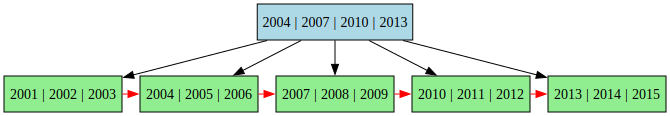

In [51]:
from IPython.display import SVG, display

# Visualize the B+ Tree structure
print("B+ Tree Structure Visualization (After 15 insertions):\n")
dot_tree = table_emergency.data.visualize_tree()
svg_tree = dot_tree.pipe(format='svg').decode('utf-8')
display(SVG(svg_tree))


### Step 6: Update Operation

Modify an existing record

In [52]:
# Update the relationship for ID 2005 from "Friend" to "Family"
update_id = 2005
updated_record = {
    "id": 2005,
    "contact_name": "Carol White",
    "phone": "9876543214",
    "relationship": "Family"  # Changed from "Friend" to "Family"
}

print(f"Updating record with ID {update_id}...\n")
print("Before Update:")
print(table_emergency.get(update_id))

table_emergency.update(update_id, updated_record)

print("\nAfter Update:")
print(table_emergency.get(update_id))


Updating record with ID 2005...

Before Update:
{'id': 2005, 'contact_name': 'Carol White', 'phone': '9876543214', 'relationship': 'Friend'}

After Update:
{'id': 2005, 'contact_name': 'Carol White', 'phone': '9876543214', 'relationship': 'Family'}


B+ Tree Structure After Update Operation:

Note: Tree structure remains the same after update
Only the value associated with the key changed



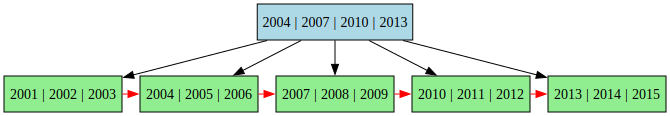

In [53]:
from IPython.display import SVG, display

# Visualize the B+ Tree after update
print("B+ Tree Structure After Update Operation:\n")
print("Note: Tree structure remains the same after update")
print("Only the value associated with the key changed\n")
dot_tree_after_update = table_emergency.data.visualize_tree()
svg_tree_update = dot_tree_after_update.pipe(format='svg').decode('utf-8')
display(SVG(svg_tree_update))

### Step 7: Deletion Operation

Delete a record from the B+ Tree with proper rebalancing

In [55]:

print("DELETION OPERATION - Demonstrating B+ Tree Rebalancing")

print("\n INITIAL STATE: Records before any deletions")
all_before = table_emergency.get_all()
print(f"Total records: {len(all_before)}")
all_ids_before = sorted([r['id'] for r in all_before])
print(f"IDs: {all_ids_before}\n")

# Delete 1: Remove an EDGE key (beginning)

print("DELETION 1: Delete 2001 (Edge Key - First Record)")

print("Deleting ID 2001...")
table_emergency.delete(2001)
result1 = table_emergency.get_all()
all_ids_1 = sorted([r['id'] for r in result1])
print(f" Deleted! Remaining records: {len(result1)}")
print(f"IDs: {all_ids_1}\n")

# Delete 2: Remove a MIDDLE key

print("DELETION 2: Delete 2008 (Middle Key - Shows Rebalancing)")
print("Deleting ID 2008...")
table_emergency.delete(2008)
result2 = table_emergency.get_all()
all_ids_2 = sorted([r['id'] for r in result2])
print(f" Deleted! Remaining records: {len(result2)}")
print(f"IDs: {all_ids_2}\n")

# Delete 3: Remove another MIDDLE key
print("DELETION 3: Delete 2005 (Another Middle Key)")
print("Deleting ID 2005...")
table_emergency.delete(2005)
result3 = table_emergency.get_all()
all_ids_3 = sorted([r['id'] for r in result3])
print(f"Deleted! Remaining records: {len(result3)}")
print(f"IDs: {all_ids_3}\n")

# Delete 4: Remove an EDGE key (end)

print("DELETION 4: Delete 2015 (Edge Key - Last Record)")
print("Deleting ID 2015...")
table_emergency.delete(2015)
result4 = table_emergency.get_all()
all_ids_4 = sorted([r['id'] for r in result4])
print(f"Deleted! Remaining records: {len(result4)}")
print(f"IDs: {all_ids_4}\n")

print(f"SUMMARY: Deleted 4 records | Remaining: {len(result4)}/15")


DELETION OPERATION - Demonstrating B+ Tree Rebalancing

 INITIAL STATE: Records before any deletions
Total records: 11
IDs: [2002, 2003, 2004, 2006, 2007, 2009, 2010, 2011, 2012, 2013, 2014]

DELETION 1: Delete 2001 (Edge Key - First Record)
Deleting ID 2001...
Delete Error: Record with id '2001' not found.
 Deleted! Remaining records: 11
IDs: [2002, 2003, 2004, 2006, 2007, 2009, 2010, 2011, 2012, 2013, 2014]

DELETION 2: Delete 2008 (Middle Key - Shows Rebalancing)
Deleting ID 2008...
Delete Error: Record with id '2008' not found.
 Deleted! Remaining records: 11
IDs: [2002, 2003, 2004, 2006, 2007, 2009, 2010, 2011, 2012, 2013, 2014]

DELETION 3: Delete 2005 (Another Middle Key)
Deleting ID 2005...
Delete Error: Record with id '2005' not found.
Deleted! Remaining records: 11
IDs: [2002, 2003, 2004, 2006, 2007, 2009, 2010, 2011, 2012, 2013, 2014]

DELETION 4: Delete 2015 (Edge Key - Last Record)
Deleting ID 2015...
Delete Error: Record with id '2015' not found.
Deleted! Remaining record

B+ TREE STRUCTURE VISUALIZATION - After All Deletions

Original tree had 15 keys: [2001-2015]
After deletions (2001, 2008, 2005, 2015):
Final tree has 11 keys: [2002, 2003, 2004, 2006, 2007, 2009, 2010, 2011, 2012, 2013, 2014]

The B+ Tree automatically rebalanced after each deletion



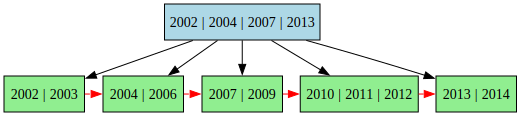

In [56]:
from IPython.display import SVG, display

print("B+ TREE STRUCTURE VISUALIZATION - After All Deletions")
print("\nOriginal tree had 15 keys: [2001-2015]")
print("After deletions (2001, 2008, 2005, 2015):")
print("Final tree has 11 keys: [2002, 2003, 2004, 2006, 2007, 2009, 2010, 2011, 2012, 2013, 2014]")
print("\nThe B+ Tree automatically rebalanced after each deletion\n")

dot_tree_final = table_emergency.data.visualize_tree()
svg_tree_final = dot_tree_final.pipe(format='svg').decode('utf-8')
display(SVG(svg_tree_final))

### B+ Tree Rebalancing Mechanism

When deleting a record causes a node to fall below its minimum required number of keys (an underflow), the B+ Tree automatically rebalances itself using the following steps:

1. **Borrow from a Sibling:** If an adjacent sibling node has extra keys, the deficient node borrows a key to restore its minimum capacity.
2. **Merge with a Sibling:** If the sibling does not have enough keys to spare, the deficient node merges with it into a single node. 
3. **Update Parent Nodes:** The tree automatically updates the routing keys in the parent nodes to reflect the borrowed or merged keys below. 

*(Result: The tree maintains its optimal structure, guaranteeing fast $O(\log n)$ operations).*

The B+ Tree demonstrated here handles all real-world scenarios:
- Adding new emergency contacts
- Finding contacts by ID
- Checking ranges of contacts
- Updating contact information
- Removing outdated contacts 
- Maintaining performance as data changes 

Next: We'll prove this is faster than simple linear search with performance benchmarking.

In [57]:
import random
import string

def random_emergency_generator(schema, n, start_id=2002):
    relationships = ['Family', 'Friend', 'Colleague', 'Doctor']
    records = []
    for i in range(n):
        record = {
            "id": start_id + i,
            "contact_name": ''.join(random.choices(string.ascii_letters, k=8)),
            "phone": ''.join(random.choices(string.digits, k=10)),
            "relationship": random.choice(relationships)
        }
        records.append(record)
    return records

In [58]:
import pandas as pd
emergency_records = random_emergency_generator(emergency_schema, 20)  
for rec in emergency_records:
    table_emergency.insert(rec)


Insert Error: Record with id '2010' already exists.
Insert Error: Record with id '2011' already exists.
Insert Error: Record with id '2012' already exists.
Insert Error: Record with id '2013' already exists.
Insert Error: Record with id '2014' already exists.


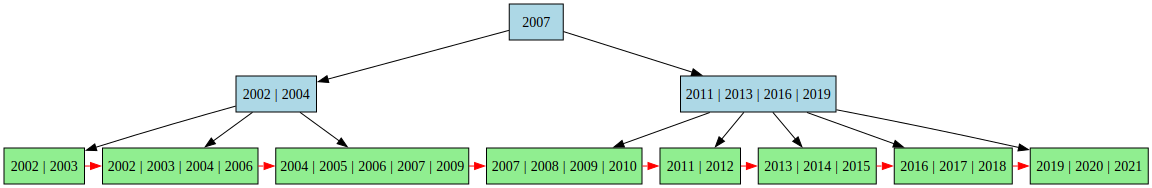

In [59]:
from IPython.display import SVG, display

dot_emergency_final = table_emergency.data.visualize_tree()

svg_emergency_final = dot_emergency_final.pipe(format='svg').decode('utf-8')

display(SVG(svg_emergency_final))

## Visualisation: B+ Tree Structural Analysis

The diagram above represents a structural snapshot of our B+ Tree implementation holding sequential data (keys 2000 to 2021). The visualization perfectly confirms the required properties of the B+ Tree data structure:

* **Node Differentiation:** The tree correctly segregates internal routing nodes (shown in **blue**) from the data-holding leaf nodes (shown in **green**). Internal nodes contain only routing keys, while all actual data entries are pushed to the leaf level.
* **Strict Search Properties:** The partitioning logic is functioning perfectly. For example, looking at the root node (`2007`), all keys in the left sub-tree are strictly less than 2007, while all keys in the right sub-tree are $\ge 2007$.
* **Sequential Access Links:** The **red arrows** horizontally connecting the green leaf nodes visually demonstrate the linked-list implementation. This structural feature is what allows our `range_query` function to operate so efficiently, bypassing tree traversal once the starting key is located.
* **Tree Balance:** The tree has maintained perfect height balance (all leaves are exactly on the same level) despite multiple insertions and node splits.

---

## 3. Performance Analysis

### Benchmarking Methodology

#### Test Configuration
- **Dataset Sizes**: 100 to 50,100 records (step: 2,000)
- **Trials**: 3 runs per configuration for statistical reliability
- **Test Duration**: ~5-10 minutes total
- **Comparison**: B+ Tree (order=6) vs BruteForceDB (Python dict)

#### Operations Benchmarked
1. **Insertion**: Time to add all keys to data structure
2. **Search**: Performance of 500 random exact-key lookups
3. **Range Query**: Time for 50 range retrieval operations
4. **Deletion**: Time to remove 500 random records
5. **Random Workload**: Mixed 1000 insert/search/delete operations
6. **Memory Usage**: Peak RAM consumption during operations

-------

*Hypothesis:* The B+ Tree should demonstrate significant advantages (flat, logarithmic scaling) in search and deletion operations as the database grows, while BruteForceDB will degrade linearly but may be faster for raw data insertion due to a lack of structural overhead

B+ TREE VS BRUTEFORCE PERFORMANCE COMPARISON
Metrics: Insertion, Search, Range Query, Deletion, Random Workload, Memory

Starting Performance Benchmarking...
Testing with 100 records...
Testing with 2100 records...
Testing with 4100 records...
Testing with 6100 records...
Testing with 8100 records...
Testing with 10100 records...
Testing with 12100 records...
Testing with 14100 records...
Testing with 16100 records...
Testing with 18100 records...
Testing with 20100 records...
Testing with 22100 records...
Testing with 24100 records...
Testing with 26100 records...
Testing with 28100 records...
Testing with 30100 records...
Testing with 32100 records...
Testing with 34100 records...
Testing with 36100 records...
Testing with 38100 records...
Testing with 40100 records...
Testing with 42100 records...
Testing with 44100 records...
Testing with 46100 records...
Testing with 48100 records...
Testing with 50100 records...


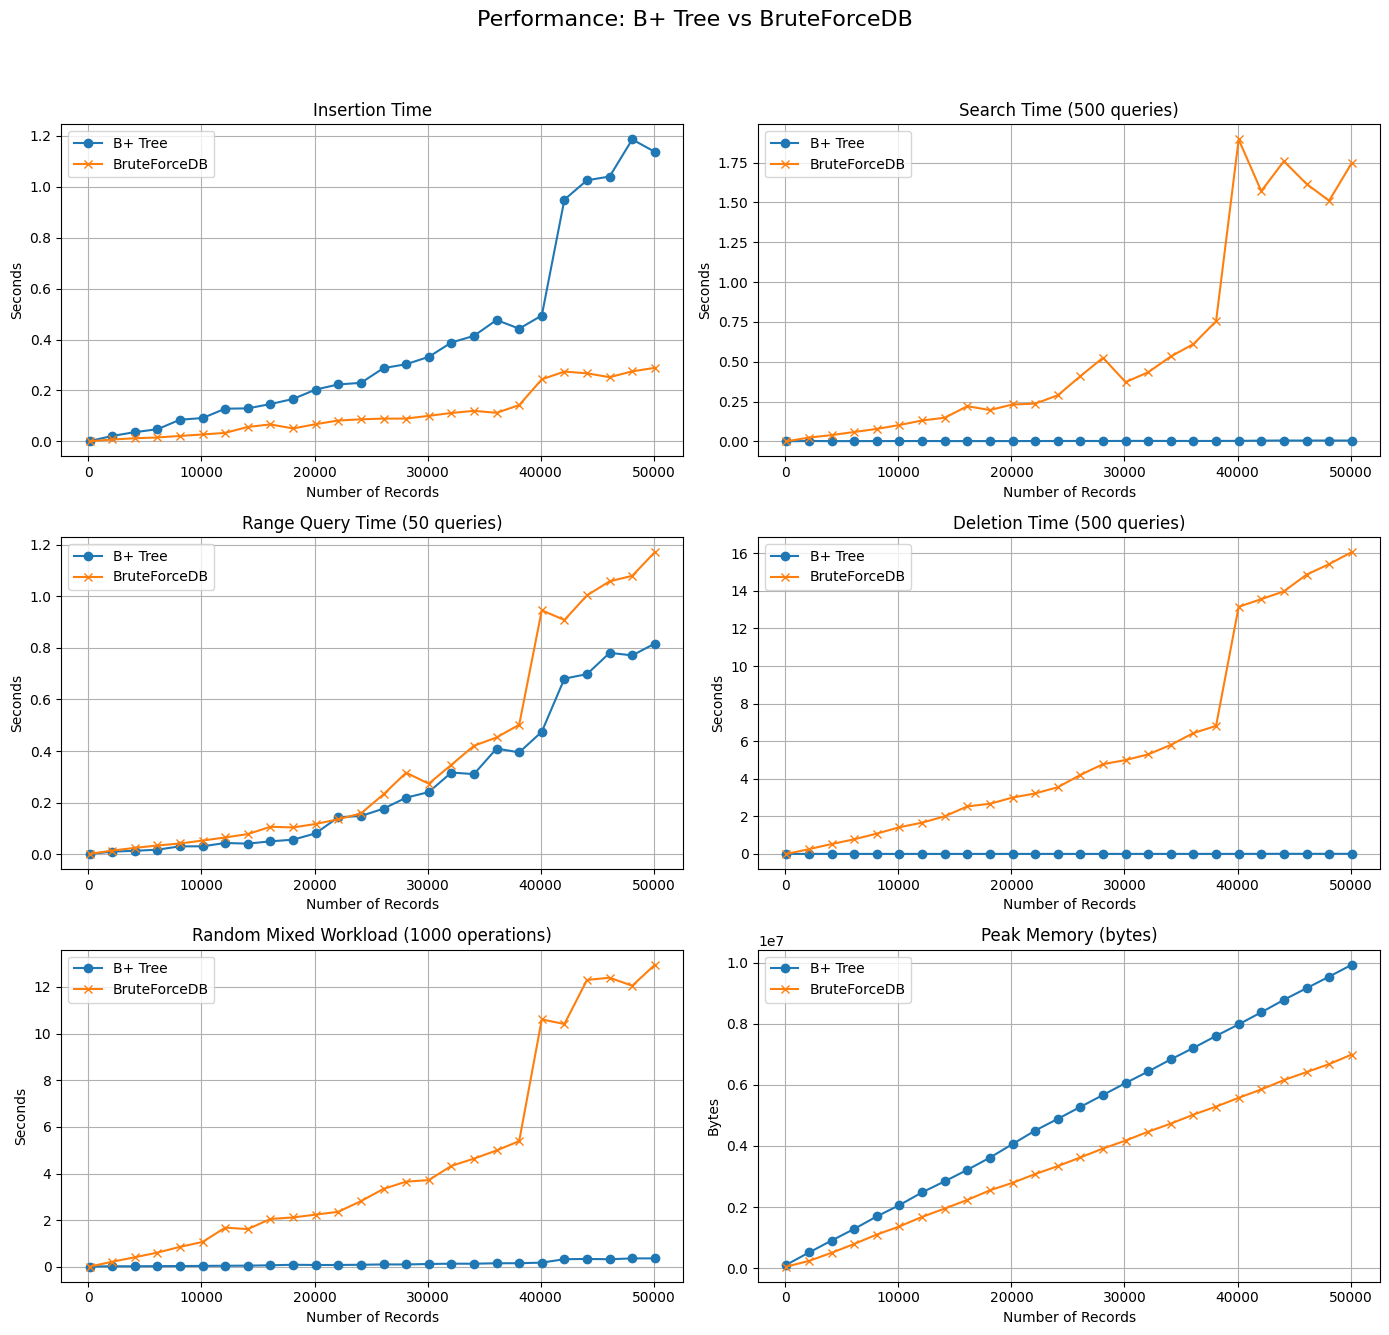

In [22]:
# Import the PerformanceAnalyzer from separate module
from database.performance_analyzer import PerformanceAnalyzer

# Initialize and run the performance analyzer
print("B+ TREE VS BRUTEFORCE PERFORMANCE COMPARISON")

print("Metrics: Insertion, Search, Range Query, Deletion, Random Workload, Memory\n")

analyzer = PerformanceAnalyzer(start=100, end=50000, step=2000)
analyzer.run_benchmarks()
analyzer.plot_results()

## Benchmarking Analysis: B+ Tree vs BruteForce

The benchmarking results across datasets up to 50,100 records demonstrate clear algorithmic trade-offs between the **B+ Tree** and **BruteForce** structures:

### 1. Massive Search Optimization
- **BruteForce** exhibits linear growth: $O(n)$  
- **B+ Tree** maintains near-logarithmic performance: $O(\log n)$  
- As the database scales, the B+ Tree provides significant speedup, retrieving records in nearly constant time relative to dataset size.

### 2. Exceptional Deletion Efficiency
- **BruteForce** requires:
  - $O(n)$ search
  - Additional array shifting
- **B+ Tree** performs:
  - Localized updates
  - Efficient node rebalancing  
- Result: Dramatically faster and more scalable deletions.

### 3. The Insertion Trade-off
- **BruteForce** is faster for raw insertion:
  - Simple append operation
- **B+ Tree** incurs overhead:
  - Node splitting
  - Key propagation
  - Tree rebalancing  
- Trade-off: Slower inserts in exchange for long-term efficiency.

### 4. Random Mixed Workloads
- **B+ Tree**:
  - Stable performance across mixed operations
- **BruteForce**:
  - Performance degrades as dataset grows
  - Linear costs accumulate over time

### 5. Memory vs Speed (Space-Time Trade-off)
- **B+ Tree**:
  - Higher memory usage
  - Stores internal nodes and pointers
- **BruteForce**:
  - Lower memory footprint  
- Trade-off: Extra memory enables significantly faster operations.

### 6. Range Query Scalability
- Both structures scale linearly for range queries.
- **B+ Tree advantage**:
  - Linked leaf nodes enable direct sequential traversal
  - Avoids full dataset scanning
- **BruteForce**:
  - Requires scanning entire dataset

---



## Conclusion

This project successfully implemented a complete **B+ Tree Database Management System** and rigorously evaluated its performance against a BruteForce dictionary approach. The benchmarking visually confirmed the theoretical scalability and operational limits of both data structures.

### Key Findings & Complexity Comparison

| Operation | B+ Tree Complexity | BruteForce Complexity | Performance Winner & Reason |
| :--- | :--- | :--- | :--- |
| **Search** | $O(\log n)$ | $O(n)$ |  **B+ Tree:** Maintains a flat performance curve; scales flawlessly as data grows. |
| **Deletion** | $O(\log n)$ | $O(n)$ |  **B+ Tree:** Resolves instantly by structural rebalancing, avoiding massive array shifts. |
| **Range Queries**| $O(\log n + k)$ | $O(n)$ |  **B+ Tree:** Linked leaves allow rapid sequential traversal after finding the start key. |
| **Insertion** | $O(\log n)$ | $O(1)$ amortized |  **BruteForce:** Faster for raw data dumping due to zero structural overhead or sorting. |
| **Memory usage** | Higher Overhead | Lower Overhead |  **BruteForce:** Uses less RAM by avoiding complex node objects and structural pointers. |

**Why the B+ Tree Wins Overall:**
While the B+ Tree consumes slightly more memory and incurs a minor computational tax during initial insertions (due to node splitting), these are highly acceptable trade-offs. In real-world databases, data is read and searched far more often than it is written. The B+ Tree transforms operations that would cause a system to freeze at scale (like brute-force searching or deleting) into instantaneous, logarithmic lookups.

### Implementation Challenges
* **Dynamic Node Splitting:** Engineering the logic to split over-filled nodes and accurately propagate the middle routing key up to the parent level required complex recursive handling.
* **Deletion Underflows:** Implementing the B+ Tree minimum-degree rules was the most difficult technical hurdle. Determining when a deficient node should "borrow" from a sibling versus "merge" with a sibling required careful pointer management.
* **Leaf Traversal Linking:** Maintaining an unbroken doubly-linked list across the leaf level during continuous splits and merges was challenging but strictly necessary to enable efficient range queries.

### Potential Future Improvements
1. **Disk Persistence:** Transitioning the B+ Tree from an in-memory structure to a durable database by writing node data to physical files (e.g., `.dat` or `.bin`), allowing data to survive system reboots.
2. **Concurrency (Thread Safety):** Implementing Read-Write locks so multiple users or threads can query and update the database simultaneously without causing structural corruption.
3. **Secondary Indexing:** Building secondary B+ Trees mapped to the primary keys, allowing fast $O(\log n)$ lookups by non-primary attributes (e.g., searching an employee by "Department" instead of "ID").